In [ ]:
metrics = {
    'SUS':     ('sus',    calc_sus_score, 0, 100),
    'TAM':     ('tam',    compute_mean,   1,   7),
    'Trust':   ('trust',  compute_mean,   1,   7),
    'Trust2':  ('trust2', compute_mean,   1,   7),
}

dfs = {}
for name, (key, func, _, _) in metrics.items():
    dfs[name] = pd.DataFrame({
        'participant_id': df['participant_id'],
        'condition':      df['condition'],
        name:             df[key].apply(func)
    })
for name in ['SUS', 'TAM', 'Trust', 'Trust2']:
    check_normality(name, dfs[name])

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal
import scikit_posthocs as sp
import matplotlib
from scipy.stats import shapiro
import warnings


warnings.filterwarnings("ignore", category=FutureWarning)

# 日本語フォント設定
matplotlib.rcParams['font.family'] = 'Meiryo'



# --- 定数定義 ---
CATEGORY_COLUMNS = {
    'sus':     list(range(1, 11)),   # SUS 1–10
    'tam':     list(range(11, 14)),  # TAM 11–13
    'trust':   list(range(14, 18)),  # Trust 14–17
    'trust2':  list(range(18, 29)),  # Trust2 18–28
    'nasa':    list(range(29, 38)),  # NASA-TLX 29–37
}
PARTICIPANT_COL = 38
CONDITION_COL   = 39
INVALID_IDS     = ['0', 'TEST', 'OLD_P1',"", "OLD_P2",  "P1_OLD","P2_OLD","P3_OLD","P4_OLD","P5_OLD","P6_OLD", ]

CONDITION_MAP = {
    1: "SpatialReference",
    2: "Pointing+SpatialReference",
    3: "Pointing",
    4: "Label"
}
 # 特定のIDのみを残す場合（必要なときにコメントアウトを外す）




# --- スコア計算 ---
def calc_sus_score(raw: list[int]) -> float:
    adj = [(s - 1) if i % 2 == 0 else (5 - s) for i, s in enumerate(raw)]
    return sum(adj) * 2.5

def compute_mean(vals: list[int]) -> float:
    return np.mean(vals)

def reverse_scoring(df: pd.DataFrame) -> pd.DataFrame:
    df['trust2'] = df['trust2'].apply(lambda v: [6 - x if i in (8,9) else x for i, x in enumerate(v)])
    df['nasa']   = df['nasa'].apply(lambda v: [6 - x if i == 3 else x for i, x in enumerate(v)])
    return df

# --- 統計検定用 ---
def run_kruskal(label: str, df: pd.DataFrame) -> tuple[float, float]:
    groups = [df[df['condition'] == c][label] for c in CONDITION_MAP.values()]
    return kruskal(*groups)

def check_normality(label: str, df: pd.DataFrame):
    print(f"\n🔍 正規性の検定（Shapiro-Wilk）: {label}")
    for cond in CONDITION_MAP.values():
        vals = df[df['condition'] == cond][label].dropna()  # ← NaNを除く
        n = len(vals)
        if n < 3:
            print(f"{label} - {cond}: ⚠ データ数不足（{n} 件）→ 検定スキップ")
            continue
        try:
            stat, p = shapiro(vals)
            mark = "✅ 正規性あり" if p > 0.05 else "❌ 正規性なし"
            print(f"{label} - {cond}: W={stat:.3f}, p={p:.4f} {mark}")
        except Exception as e:
            print(f"{label} - {cond}: ⚠ 検定失敗 ({e})")


# --- データ読み込み & 前処理 ---

def load_and_preprocess(filepath: str) -> pd.DataFrame:
    df = pd.read_csv(filepath, encoding='utf-8')


    
    # 参加者ID・条件情報の処理
    df['participant_id'] = df.iloc[:, PARTICIPANT_COL].astype(str)
    df['condition'] = df.iloc[:, CONDITION_COL].astype(int)

    # 無効なID除外
    df = df[~df['participant_id'].isin(INVALID_IDS)]
 
    print(len(df["participant_id"]))
    # df = df[df['participant_id'].isin(["P3"])]
    print(len(df))
    df = df.reset_index(drop=True)

    # SUS, TAM, Trust, Trust2, NASA などのスコア用リスト列を作成
    for key, cols in CATEGORY_COLUMNS.items():
        df[key] = df.iloc[:, cols].apply(lambda r: r.astype(int).tolist(), axis=1)
    
    
    return df

def kruskal_eta_squared(H: float, k: int, n: int) -> float:
    return (H - k + 1) / (n - k)

# --- メイン ---
def main():
    # データ読み込み・前処理
    df = load_and_preprocess('SurvayResult.csv')
    df = reverse_scoring(df)

    # スコア DataFrame 作成
    metrics = {
        'SUS':     ('sus',    calc_sus_score, 0, 100),
        'TAM':     ('tam',    compute_mean,   1,   7),
        'Trust':   ('trust',  compute_mean,   1,   7),
        'Trust2':  ('trust2', compute_mean,   1,   7),
        'NASA-TLX':('nasa',   compute_mean,   1,   7),
    }
    dfs = {}
    for name, (key, func, ymin, ymax) in metrics.items():
        dfs[name] = pd.DataFrame({
            'participant_id': df['participant_id'],
            'condition':      df['condition'],
            name:              df[key].apply(func)
        })

    # 条件ラベル適用
    ordered_conditions = ["SpatialReference", "Pointing+SpatialReference", "Pointing", "Label"]
    for dfm in dfs.values():
        dfm['condition'] = dfm['condition'].map(CONDITION_MAP)

    # 🔽 条件の並び順を明示的に指定
    ordered_conditions = ["SpatialReference", "Pointing+SpatialReference", "Pointing", "Label"]
    for dfm in dfs.values():
        dfm['condition'] = pd.Categorical(dfm['condition'], categories=ordered_conditions, ordered=True)
    # 1. 基本プロット: 箱ひげ＋スウォーム & 平均±SEバー
    fig1, axes1 = plt.subplots(len(metrics), 2, figsize=(14, 5*len(metrics)))
    for i, (name, dfm) in enumerate(dfs.items()):
        ymin, ymax = metrics[name][2], metrics[name][3]
        # 箱ひげ＋スウォーム
        ax = axes1[i, 0]
        sns.boxplot(data=dfm, x='condition', y=name, palette='pastel', ax=ax)
        sns.swarmplot(data=dfm, x='condition', y=name, color='k', alpha=0.6, ax=ax)
        ax.set(title=f"{name} の条件別比較", ylim=(ymin, ymax))
        # 平均±SEバー
        ax2 = axes1[i, 1]
        means = dfm.groupby('condition')[name].mean()
        sems  = dfm.groupby('condition')[name].sem()
        ax2.bar(means.index, means, yerr=sems, capsize=5)
        ax2.set(title=f"{name} 平均 ± SE", ylim=(ymin, ymax))
    plt.tight_layout(); plt.suptitle('条件別ユーザビリティ・受容性評価', y=1.02)
    plt.savefig('survey_plots.png', dpi=300)

    # 2. 統計検定 & 結果表示
    print()
    stats = {}
    for name in ['SUS','TAM','Trust','Trust2']:
        stat, p = run_kruskal(name, dfs[name])
        has_significance = p < 0.05
        mark = "✅ 有意差あり" if has_significance else "❌ 有意差なし"
        print(f"{name}: H={stat:.3f}, p={p} {mark}")
        stats[name] = (stat, p)

        # 有意差があればDunn事後検定
        if has_significance:
            print("→ Dunnの事後検定（Bonferroni補正）結果:")
            print(sp.posthoc_dunn(dfs[name], val_col=name, group_col='condition', p_adjust='bonferroni'))
            print()
    # 各条件（行） × 各指標（列）の平均スコアを作成
    summary = pd.DataFrame(
    {
        metric: [
            dfs[metric][dfs[metric]['condition'] == cond][metric].mean()
            for cond in CONDITION_MAP.values()
        ]
        for metric in ['SUS', 'TAM', 'Trust', 'Trust2']
    },
        index=CONDITION_MAP.values()  # 行名を条件のラベルに
    )

    # 小数点以下2桁で丸めて表示
    print(summary.round(2))

    # 4. 効果量 η² を表示
    print("\n効果量 η²（Kruskal-Wallis）:")
    for name in ['SUS','TAM','Trust','Trust2']:
        H, p = stats[name]
        n = len(dfs[name])  # データ数（NaN除外してないならOK）
        k = dfs[name]['condition'].nunique()
        eta2 = kruskal_eta_squared(H, k, n)
        print(f"{name}: η² = {eta2:.3f}")

    


    # 3. 統計結果付きボックスプロット
    fig2, axes2 = plt.subplots(2, 2, figsize=(12, 10))
    for ax, name in zip(axes2.flat, ['SUS','TAM','Trust','Trust2']):
        dfm = dfs[name]
        stat, p = stats[name]
        sns.boxplot(data=dfm, x='condition', y=name, palette='pastel', ax=ax)
        ax.set_title(f"{name} (H={stat:.2f}, p={p})")
        ax.set_xlabel(''); ax.set_ylabel(name)
    plt.tight_layout(); plt.suptitle('統計検定結果付き分布図', y=1.02)
    plt.savefig('stats_boxplots.png', dpi=300)
    plt.show()



84
84

SUS: H=34.307, p=1.7065649562049688e-07 ✅ 有意差あり
→ Dunnの事後検定（Bonferroni補正）結果:
                           SpatialReference  Pointing+SpatialReference  \
SpatialReference                   1.000000               8.603055e-04   
Pointing+SpatialReference          0.000860               1.000000e+00   
Pointing                           0.085615               1.000000e+00   
Label                              0.776403               6.269760e-07   

                           Pointing         Label  
SpatialReference           0.085615  7.764029e-01  
Pointing+SpatialReference  1.000000  6.269760e-07  
Pointing                   1.000000  4.369112e-04  
Label                      0.000437  1.000000e+00  

TAM: H=31.056, p=8.27245312958514e-07 ✅ 有意差あり
→ Dunnの事後検定（Bonferroni補正）結果:
                           SpatialReference  Pointing+SpatialReference  \
SpatialReference                   1.000000                   0.000094   
Pointing+SpatialReference          0.000094                  

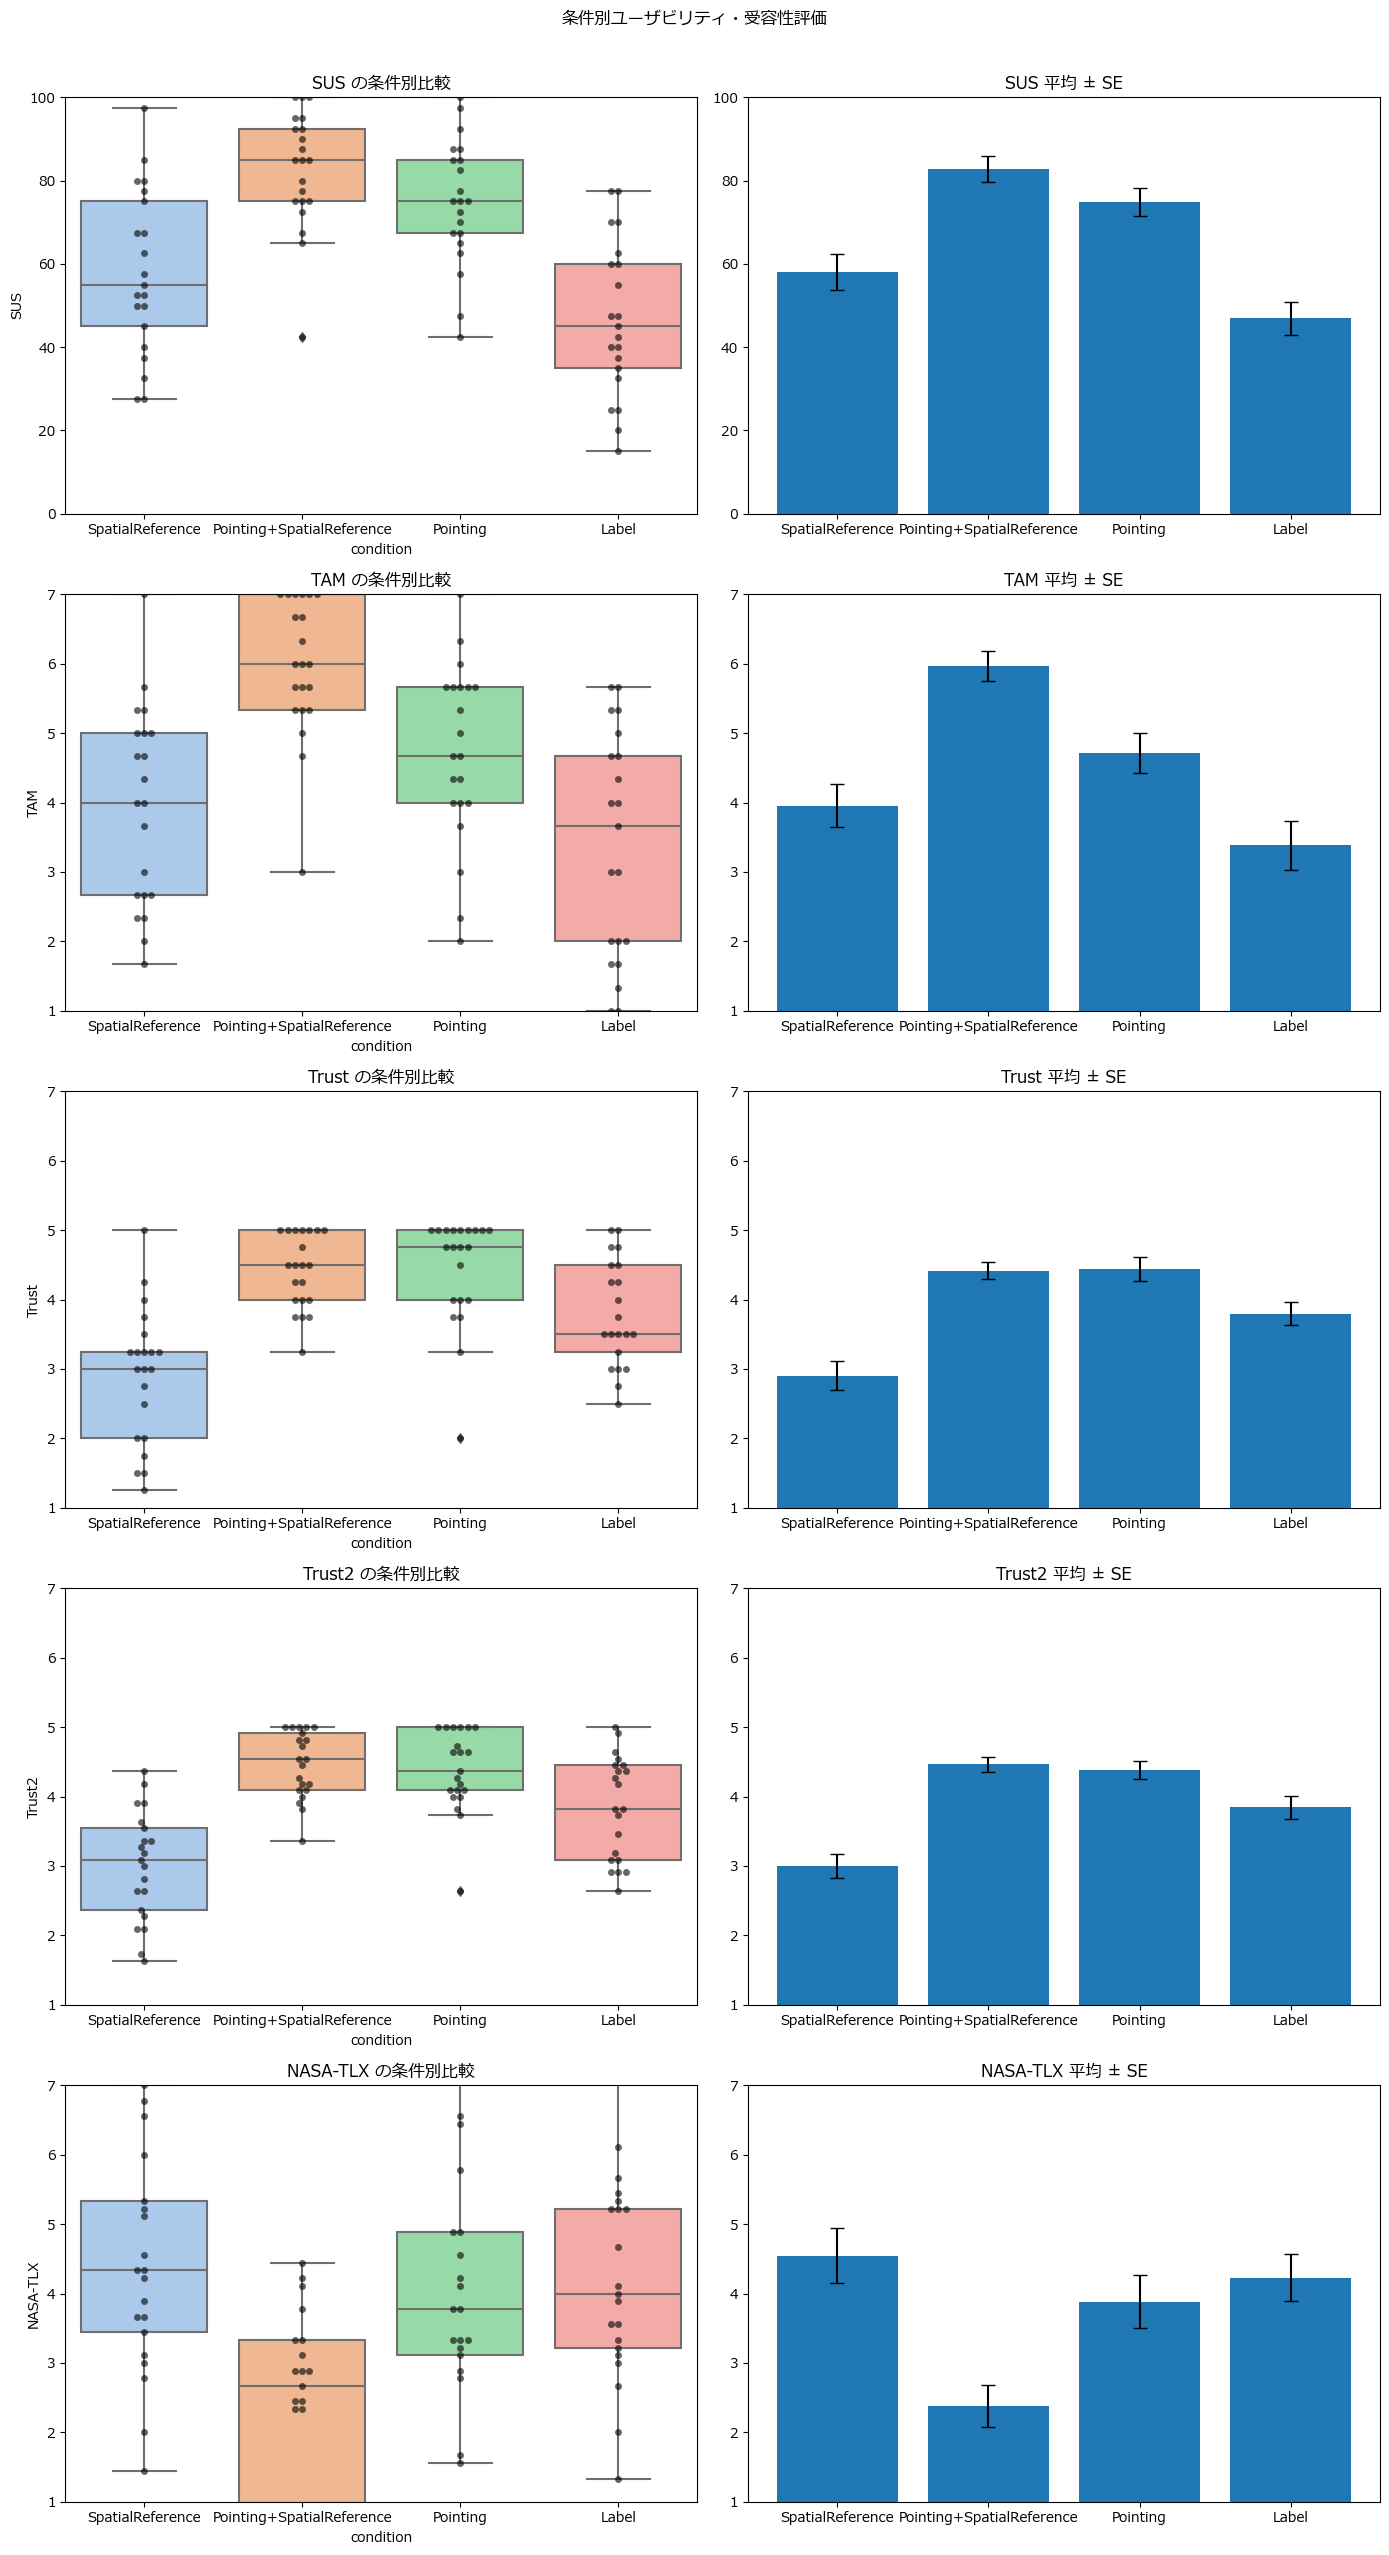

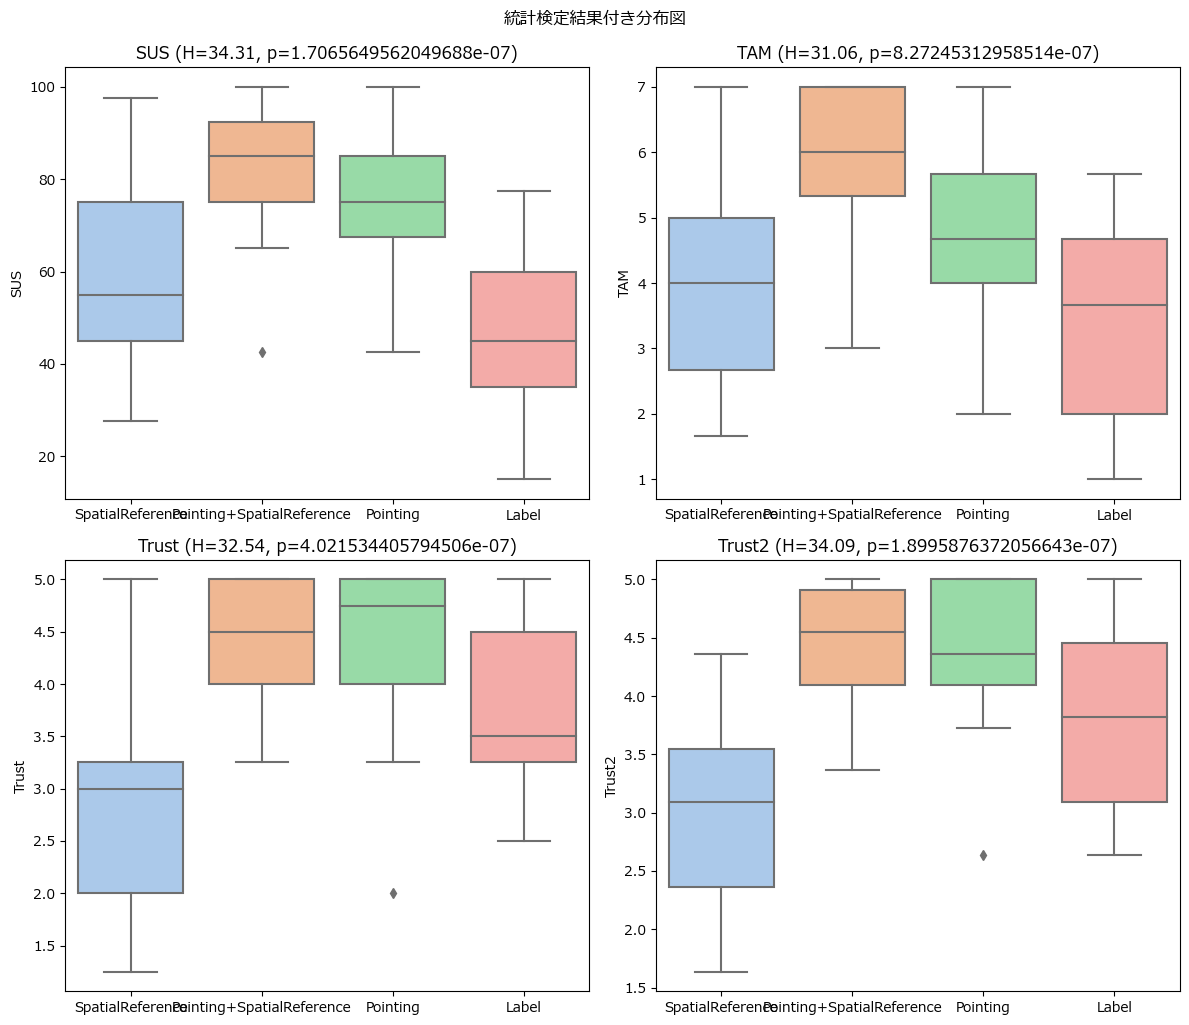

In [86]:
main()


🔍 正規性の検定（Shapiro-Wilk）: SUS
SUS - SpatialReference: W=0.965, p=0.7322 ✅ 正規性あり
SUS - Pointing+SpatialReference: W=0.945, p=0.3834 ✅ 正規性あり
SUS - Pointing: W=0.938, p=0.2959 ✅ 正規性あり
SUS - Label: W=0.976, p=0.9126 ✅ 正規性あり

🔍 正規性の検定（Shapiro-Wilk）: TAM
TAM - SpatialReference: W=0.952, p=0.4920 ✅ 正規性あり
TAM - Pointing+SpatialReference: W=0.872, p=0.0239 ❌ 正規性なし
TAM - Pointing: W=0.922, p=0.1582 ✅ 正規性あり
TAM - Label: W=0.875, p=0.0262 ❌ 正規性なし

🔍 正規性の検定（Shapiro-Wilk）: Trust
Trust - SpatialReference: W=0.966, p=0.7393 ✅ 正規性あり
Trust - Pointing+SpatialReference: W=0.856, p=0.0134 ❌ 正規性なし
Trust - Pointing: W=0.742, p=0.0004 ❌ 正規性なし
Trust - Label: W=0.952, p=0.4844 ✅ 正規性あり

🔍 正規性の検定（Shapiro-Wilk）: Trust2
Trust2 - SpatialReference: W=0.921, p=0.1514 ✅ 正規性あり
Trust2 - Pointing+SpatialReference: W=0.870, p=0.0220 ❌ 正規性なし
Trust2 - Pointing: W=0.948, p=0.4248 ✅ 正規性あり
Trust2 - Label: W=0.929, p=0.2128 ✅ 正規性あり


In [97]:
df['condition'] = df['condition'].map(CONDITION_MAP)